In [24]:
!pip install seaborn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [25]:
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.dpi'     : 120,
    'font.family'    : 'sans-serif',
    'axes.titlesize' : 13,
    'axes.labelsize' : 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

BLUE   = "#1F3864"
TEAL   = "#2E75B6"
ORANGE = "#E87722"

print(" Libraries loaded successfully!")

 Libraries loaded successfully!


In [26]:
from google.colab import files

print(" Please upload these 3 files exported from SSMS:")
print(" 1. transactions.csv")
print(" 2. customer_response.csv")
print(" 3. customer_summary.csv")
print()

uploaded = files.upload()
print(f"\n Uploaded files: {list(uploaded.keys())}")

 Please upload these 3 files exported from SSMS:
 1. transactions.csv
 2. customer_response.csv
 3. customer_summary.csv



Saving customer_response.csv to customer_response.csv
Saving transactions.csv to transactions.csv
Saving vw_customer_summary.csv to vw_customer_summary.csv

 Uploaded files: ['customer_response.csv', 'transactions.csv', 'vw_customer_summary.csv']


In [33]:
df_transactions = pd.read_csv(
    'transactions.csv',
    header=None,
    names=['transaction_id','customer_id','trans_date','tran_amount',
           'trans_year','trans_month','trans_month_name','trans_quarter',
           'total_sales'],
    parse_dates=['trans_date']
)

df_response = pd.read_csv(
    'customer_response.csv',
    header=None,
    names=['response_id','customer_id','response']
)

df_customers = pd.read_csv(
    'customer_summary.csv',
    header=None,
    names=['customer_id','total_transactions','total_spent',
           'avg_transaction_value','min_transaction','max_transaction',
           'first_purchase_date','last_purchase_date',
           'customer_lifespan_days','campaign_response'],
    parse_dates=['first_purchase_date','last_purchase_date']
)

print(f" Transactions loaded   : {len(df_transactions):,} rows")
print(f" Response loaded       : {len(df_response):,} rows")
print(f" Customer summary      : {len(df_customers):,} rows")

 Transactions loaded   : 125,000 rows
 Response loaded       : 13,768 rows
 Customer summary      : 6,889 rows


In [34]:
# Run this quick check
print(df_response.head())
print()
print(df_response['response'].value_counts())
print()
print(f"Unique customers in response: {df_response['customer_id'].nunique()}")

   response_id customer_id  response
0            1      CS1112         0
1            2      CS1113         0
2            3      CS1114         1
3            4      CS1115         1
4            5      CS1116         1

response
0    12474
1     1294
Name: count, dtype: int64

Unique customers in response: 6884


In [35]:
print("=" * 55)
print("TRANSACTIONS — Shape & Sample")
print("=" * 55)
print(f"Rows : {len(df_transactions):,}")
print(f"Cols : {list(df_transactions.columns)}")
print()
print(df_transactions.head())

print("\n" + "=" * 55)
print("STATISTICAL SUMMARY")
print("=" * 55)
print(df_transactions['tran_amount'].describe().round(2))

print("\n" + "=" * 55)
print("DATE RANGE")
print("=" * 55)
print(f"Earliest : {df_transactions['trans_date'].min().date()}")
print(f"Latest   : {df_transactions['trans_date'].max().date()}")
print(f"Years    : {sorted(df_transactions['trans_year'].unique())}")

print("\n" + "=" * 55)
print("CAMPAIGN RESPONSE SUMMARY")
print("=" * 55)
counts = df_response['response'].value_counts()
print(f"Did Not Respond : {counts[0]:,}")
print(f"Responded       : {counts[1]:,}")
print(f"Response Rate   : {df_response['response'].mean()*100:.2f}%")


TRANSACTIONS — Shape & Sample
Rows : 125,000
Cols : ['transaction_id', 'customer_id', 'trans_date', 'tran_amount', 'trans_year', 'trans_month', 'trans_month_name', 'trans_quarter', 'total_sales']

   transaction_id customer_id trans_date  tran_amount  trans_year  \
0               1      CS7943 2015-03-10         47.0        2015   
1               2      CS8884 2013-11-06         24.0        2013   
2               3      CS8377 2013-08-19         73.0        2013   
3               4      CS8769 2011-06-13         19.0        2011   
4               5      CS7308 2013-08-21         37.0        2013   

   trans_month trans_month_name trans_quarter  total_sales  
0            3            March            Q1         47.0  
1           11         November            Q4         24.0  
2            8           August            Q3         73.0  
3            6             June            Q2         19.0  
4            8           August            Q3         37.0  

STATISTICAL SUMMARY
c

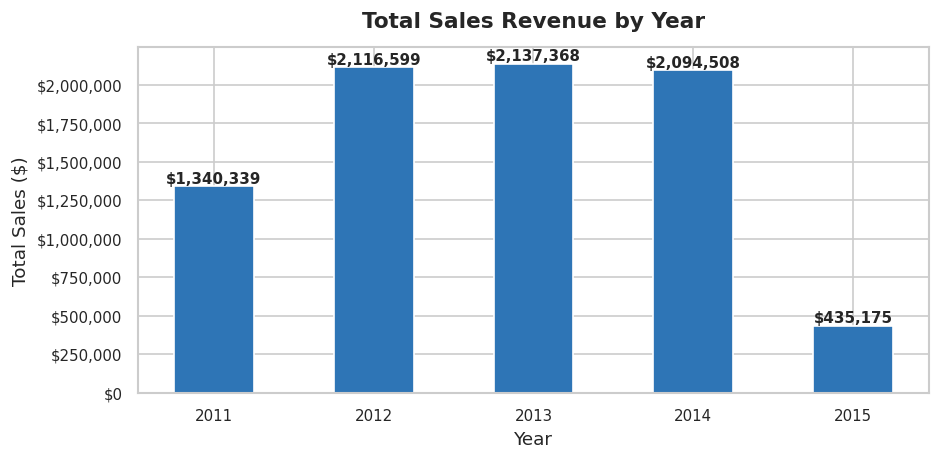

 Chart 1 saved


In [42]:
sales_by_year = (df_transactions
                 .groupby('trans_year')['total_sales']
                 .sum()
                 .reset_index())

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(
    sales_by_year['trans_year'].astype(str),
    sales_by_year['total_sales'],
    color=TEAL, edgecolor='white', width=0.5
)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 500,
            f"${bar.get_height():,.0f}",
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title("Total Sales Revenue by Year", fontweight='bold', pad=12)
ax.set_xlabel("Year")
ax.set_ylabel("Total Sales ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:,.0f}"))
plt.tight_layout()
plt.savefig("chart1_sales_by_year.png", bbox_inches='tight')
plt.show()
print(" Chart 1 saved")


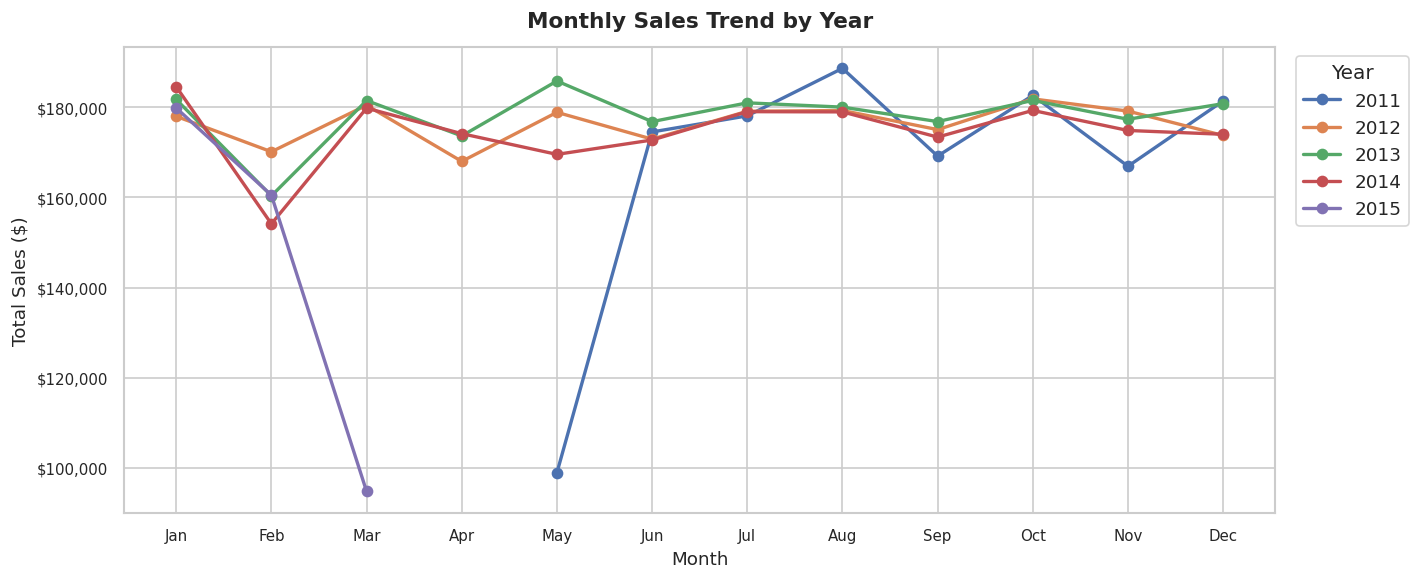

 Chart 2 saved


In [43]:
sales_by_month = (df_transactions
                  .groupby(['trans_year','trans_month'])['total_sales']
                  .sum()
                  .reset_index())

fig, ax = plt.subplots(figsize=(12, 5))
for year in sorted(sales_by_month['trans_year'].unique()):
    data = sales_by_month[sales_by_month['trans_year'] == year]
    ax.plot(data['trans_month'], data['total_sales'],
            marker='o', linewidth=2, label=str(year))

ax.set_title("Monthly Sales Trend by Year", fontweight='bold', pad=12)
ax.set_xlabel("Month")
ax.set_ylabel("Total Sales ($)")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec'])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:,.0f}"))
ax.legend(title="Year", bbox_to_anchor=(1.01,1), loc='upper left')
plt.tight_layout()
plt.savefig("chart2_monthly_trend.png", bbox_inches='tight')
plt.show()
print(" Chart 2 saved")

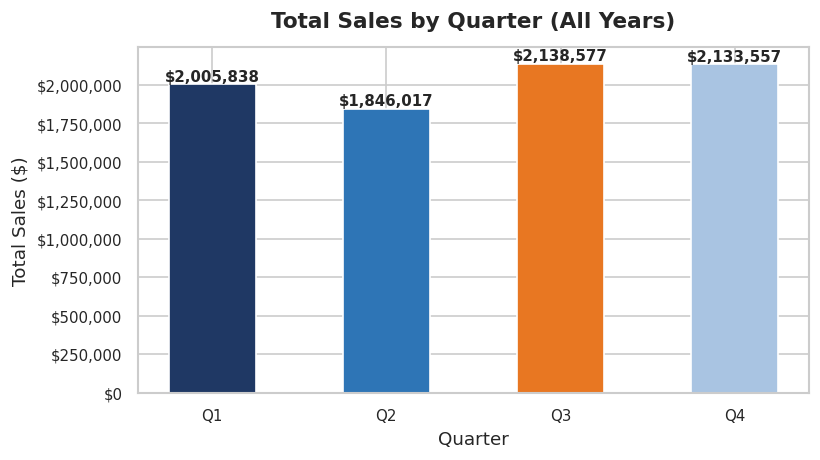

 Chart 3 saved


In [44]:
sales_by_quarter = (df_transactions
                    .groupby('trans_quarter')['total_sales']
                    .sum()
                    .reset_index()
                    .sort_values('trans_quarter'))

fig, ax = plt.subplots(figsize=(7, 4))
colors = [BLUE, TEAL, ORANGE, "#A9C4E2"]
bars = ax.bar(sales_by_quarter['trans_quarter'],
              sales_by_quarter['total_sales'],
              color=colors, edgecolor='white', width=0.5)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 500,
            f"${bar.get_height():,.0f}",
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title("Total Sales by Quarter (All Years)", fontweight='bold', pad=12)
ax.set_xlabel("Quarter")
ax.set_ylabel("Total Sales ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:,.0f}"))
plt.tight_layout()
plt.savefig("chart3_sales_by_quarter.png", bbox_inches='tight')
plt.show()
print(" Chart 3 saved")


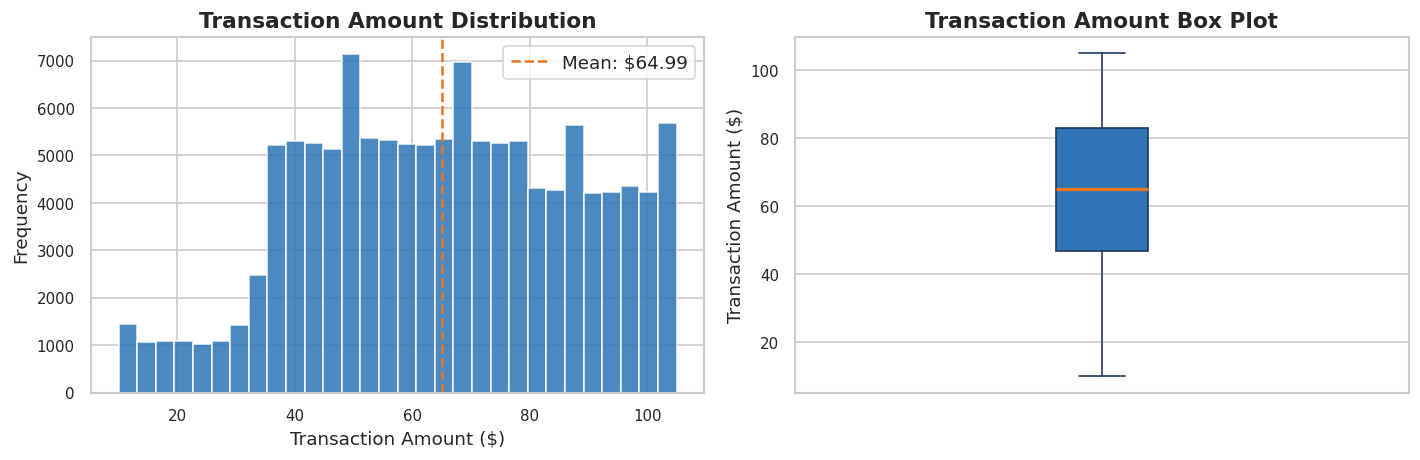

 Chart 4 saved


In [45]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(df_transactions['tran_amount'], bins=30,
             color=TEAL, edgecolor='white', alpha=0.85)
axes[0].axvline(df_transactions['tran_amount'].mean(),
                color=ORANGE, linestyle='--', linewidth=1.5,
                label=f"Mean: ${df_transactions['tran_amount'].mean():.2f}")
axes[0].set_title("Transaction Amount Distribution", fontweight='bold')
axes[0].set_xlabel("Transaction Amount ($)")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# Boxplot
axes[1].boxplot(df_transactions['tran_amount'],
                patch_artist=True,
                boxprops=dict(facecolor=TEAL, color=BLUE),
                medianprops=dict(color=ORANGE, linewidth=2),
                whiskerprops=dict(color=BLUE),
                capprops=dict(color=BLUE))
axes[1].set_title("Transaction Amount Box Plot", fontweight='bold')
axes[1].set_ylabel("Transaction Amount ($)")
axes[1].set_xticks([])

plt.tight_layout()
plt.savefig("chart4_amount_distribution.png", bbox_inches='tight')
plt.show()
print(" Chart 4 saved")


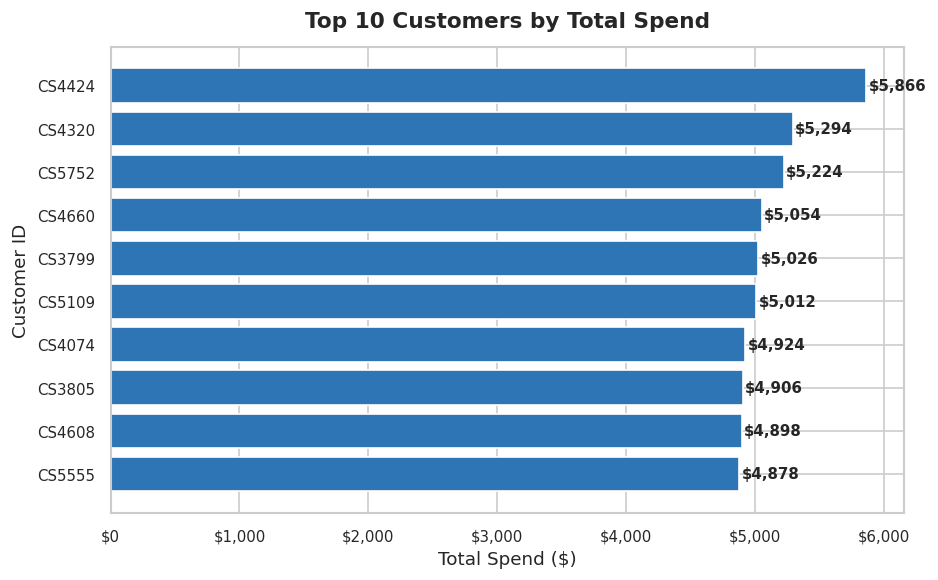

Chart 5 saved


In [46]:
top10 = (df_customers
         .nlargest(10, 'total_spent')
         .sort_values('total_spent'))

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(top10['customer_id'], top10['total_spent'],
               color=TEAL, edgecolor='white')

for bar in bars:
    ax.text(bar.get_width() + 20,
            bar.get_y() + bar.get_height()/2,
            f"${bar.get_width():,.0f}",
            va='center', fontsize=9, fontweight='bold')

ax.set_title("Top 10 Customers by Total Spend", fontweight='bold', pad=12)
ax.set_xlabel("Total Spend ($)")
ax.set_ylabel("Customer ID")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:,.0f}"))
plt.tight_layout()
plt.savefig("chart5_top10_customers.png", bbox_inches='tight')
plt.show()
print("Chart 5 saved")


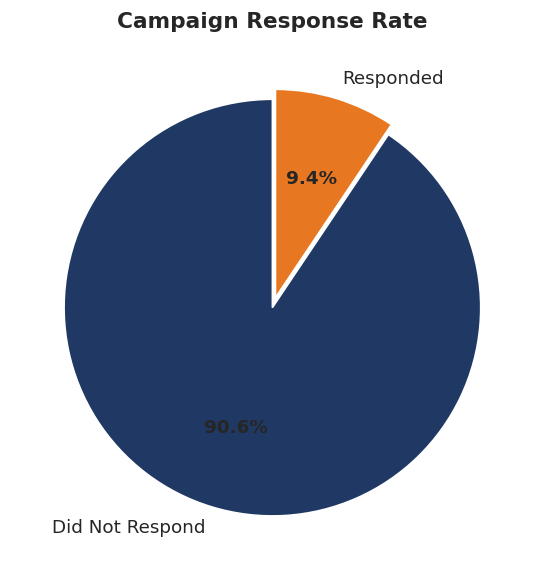

 Chart 6 saved


In [47]:
response_counts = df_response['response'].value_counts()

fig, ax = plt.subplots(figsize=(6, 5))
wedges, texts, autotexts = ax.pie(
    response_counts,
    labels=['Did Not Respond', 'Responded'],
    colors=[BLUE, ORANGE],
    autopct='%1.1f%%',
    explode=(0, 0.05),
    startangle=90,
    textprops={'fontsize': 11}
)
for at in autotexts:
    at.set_fontweight('bold')
ax.set_title("Campaign Response Rate", fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig("chart6_response_rate.png", bbox_inches='tight')
plt.show()
print(" Chart 6 saved")

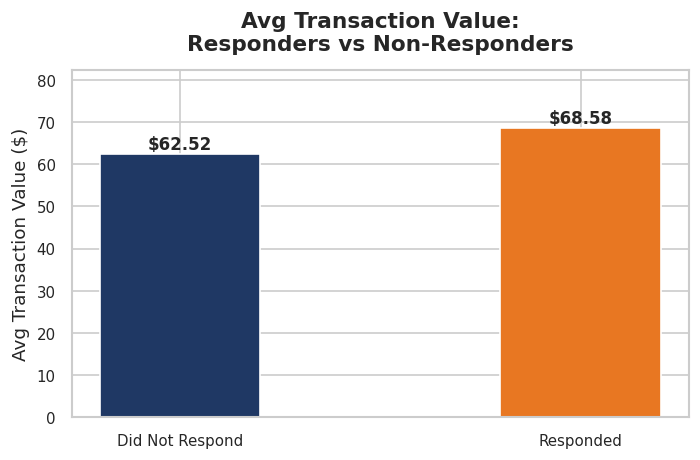

 Chart 7 saved


In [48]:
avg_by_response = (df_customers
                   .groupby('campaign_response')['avg_transaction_value']
                   .mean()
                   .reset_index())
avg_by_response['label'] = avg_by_response['campaign_response'].map(
    {0: 'Did Not Respond', 1: 'Responded'})

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(avg_by_response['label'],
              avg_by_response['avg_transaction_value'],
              color=[BLUE, ORANGE], edgecolor='white', width=0.4)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.2,
            f"${bar.get_height():.2f}",
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title("Avg Transaction Value:\nResponders vs Non-Responders",
             fontweight='bold', pad=12)
ax.set_ylabel("Avg Transaction Value ($)")
ax.set_ylim(0, avg_by_response['avg_transaction_value'].max() * 1.2)
plt.tight_layout()
plt.savefig("chart7_responders_vs_non.png", bbox_inches='tight')
plt.show()
print(" Chart 7 saved")

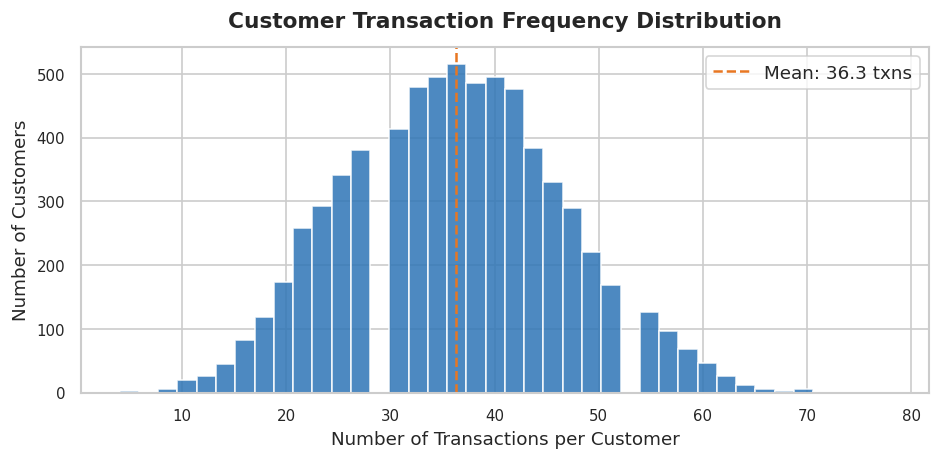

 Chart 8 saved


In [49]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df_customers['total_transactions'], bins=40,
        color=TEAL, edgecolor='white', alpha=0.85)
ax.axvline(df_customers['total_transactions'].mean(),
           color=ORANGE, linestyle='--', linewidth=1.5,
           label=f"Mean: {df_customers['total_transactions'].mean():.1f} txns")
ax.set_title("Customer Transaction Frequency Distribution",
             fontweight='bold', pad=12)
ax.set_xlabel("Number of Transactions per Customer")
ax.set_ylabel("Number of Customers")
ax.legend()
plt.tight_layout()
plt.savefig("chart8_txn_frequency.png", bbox_inches='tight')
plt.show()
print(" Chart 8 saved")

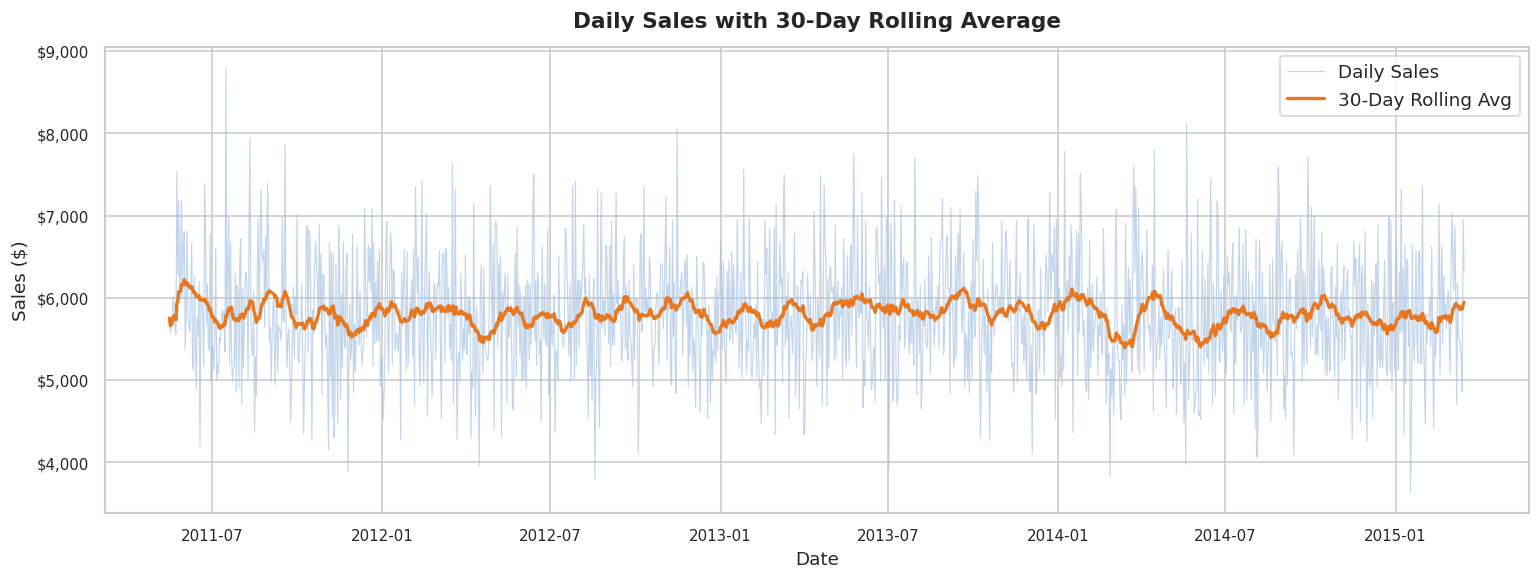

 Chart 9 saved


In [50]:
daily_sales = (df_transactions
               .groupby('trans_date')['total_sales']
               .sum()
               .reset_index()
               .sort_values('trans_date'))

daily_sales['rolling_30d'] = (daily_sales['total_sales']
                               .rolling(window=30, min_periods=1)
                               .mean())

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(daily_sales['trans_date'], daily_sales['total_sales'],
        color='#A9C4E2', linewidth=0.7, alpha=0.7, label='Daily Sales')
ax.plot(daily_sales['trans_date'], daily_sales['rolling_30d'],
        color=ORANGE, linewidth=2, label='30-Day Rolling Avg')

ax.set_title("Daily Sales with 30-Day Rolling Average",
             fontweight='bold', pad=12)
ax.set_xlabel("Date")
ax.set_ylabel("Sales ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:,.0f}"))
ax.legend()
plt.tight_layout()
plt.savefig("chart9_time_series.png", bbox_inches='tight')
plt.show()
print(" Chart 9 saved")

COHORT ANALYSIS — First Purchase Year
 first_year  customer_count  avg_total_spent  avg_transactions
       2011            6501      2406.891094         36.873404
       2012             376      1564.579787         26.757979
       2013              12       907.166667         16.166667


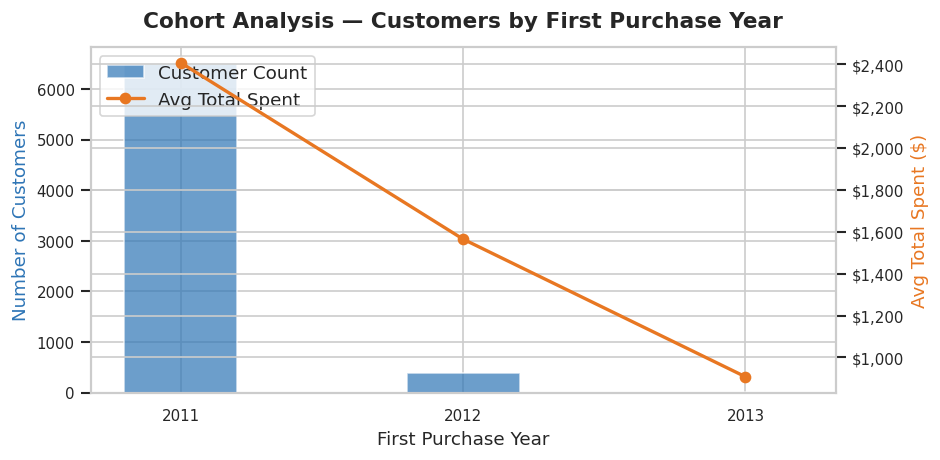

 Chart 10 saved


In [51]:
df_customers['first_year'] = pd.to_datetime(
    df_customers['first_purchase_date']).dt.year

cohort = (df_customers
          .groupby('first_year')
          .agg(
              customer_count   = ('customer_id', 'count'),
              avg_total_spent  = ('total_spent', 'mean'),
              avg_transactions = ('total_transactions', 'mean')
          )
          .reset_index())

print("=" * 55)
print("COHORT ANALYSIS — First Purchase Year")
print("=" * 55)
print(cohort.to_string(index=False))

fig, ax1 = plt.subplots(figsize=(8, 4))
ax2 = ax1.twinx()

ax1.bar(cohort['first_year'].astype(str),
        cohort['customer_count'],
        color=TEAL, alpha=0.7, width=0.4, label='Customer Count')
ax2.plot(cohort['first_year'].astype(str),
         cohort['avg_total_spent'],
         color=ORANGE, marker='o', linewidth=2, label='Avg Total Spent')

ax1.set_title("Cohort Analysis — Customers by First Purchase Year",
              fontweight='bold', pad=12)
ax1.set_xlabel("First Purchase Year")
ax1.set_ylabel("Number of Customers", color=TEAL)
ax2.set_ylabel("Avg Total Spent ($)", color=ORANGE)
ax2.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x,_: f"${x:,.0f}"))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
plt.savefig("chart10_cohort_analysis.png", bbox_inches='tight')
plt.show()
print(" Chart 10 saved")

In [52]:
best_year = sales_by_year.loc[
    sales_by_year['total_sales'].idxmax(), 'trans_year']
top_customer = df_customers.loc[
    df_customers['total_spent'].idxmax(), 'customer_id']

print("=" * 55)
print("          KEY INSIGHTS SUMMARY")
print("=" * 55)
print(f"  Total Transactions    : {len(df_transactions):,}")
print(f"  Unique Customers      : {df_transactions['customer_id'].nunique():,}")
print(f"  Total Revenue         : ${df_transactions['total_sales'].sum():,.2f}")
print(f"  Avg Transaction Value : ${df_transactions['total_sales'].mean():,.2f}")
print(f"  Date Range            : {df_transactions['trans_date'].min().date()} "
      f"→ {df_transactions['trans_date'].max().date()}")
print(f"  Campaign Response Rate: {df_response['response'].mean()*100:.2f}%")
print(f"  Best Year by Revenue  : {best_year}")
print(f"  Top Customer (Spend)  : {top_customer}")
print("=" * 55)

          KEY INSIGHTS SUMMARY
  Total Transactions    : 125,000
  Unique Customers      : 6,889
  Total Revenue         : $8,123,989.00
  Avg Transaction Value : $64.99
  Date Range            : 2011-05-16 → 2015-03-16
  Campaign Response Rate: 9.40%
  Best Year by Revenue  : 2013
  Top Customer (Spend)  : CS4424


In [55]:
import zipfile, os

chart_files = [f for f in os.listdir() if f.endswith('.png')]
with zipfile.ZipFile('Charts.zip', 'w') as zipf:
    for chart in chart_files:
        zipf.write(chart)

files.download('Charts.zip')
print(f"{len(chart_files)} charts downloaded as Charts.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

10 charts downloaded as Charts.zip
